In [1]:
%pip install qiskit[visualization]==1.1.0

Note: you may need to restart the kernel to use updated packages.


In [2]:
import qiskit

In [3]:
qiskit.__version__

'1.1.0'

In [4]:
%pip install qiskit_aer
%pip install qiskit_ibm_runtime
%pip install matplotlib
%pip install pylatexenc
%pip install qiskit-transpiler-service

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [5]:
# Built-in modules
import math

# Imports from Qiskit
from qiskit import QuantumCircuit
from qiskit.circuit.library import GroverOperator, MCMT, ZGate
from qiskit.visualization import plot_distribution
from qiskit import transpile
from qiskit_aer import Aer

# Import from Qiskit Runtime
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import SamplerV2 as Sampler

In [6]:
simulator = Aer.get_backend('qasm_simulator')
backend=simulator

In [7]:
def grover_oracle(marked_states):
    """Build a grover oracle for multiple marked states 
    Here we assume all input marked states have the same number of bits
    
    Parameters:
        marked_states (str or list): Marked states of oracle
        
    Returns:
        QuantumCircuit: Quantum circuit representing Grover oracle
        """
    if not isinstance(marked_states, list):
        marked_states = [marked_states]
    # Compute the number of qubits in circuit
    num_qubits = len(marked_states[0])
    
    qc = QuantumCircuit(num_qubits)
    # Mark much target state in the input list
    for target in marked_states:
        # Flip target bit-string to match Qiskit bit-ordering
        rev_target = target[::-1]
        # Find the indices of all the '0' elements in bit-ordering
        zero_inds = [ind for ind in range(num_qubits) if rev_target.startswith("0", ind)]
        # Add a multi-controlled Z- gate with pre and post-applied X-gates (open - controls)
        # Where the target bit-string has a '0' entry
        qc.x(zero_inds)
        qc.compose(MCMT(ZGate(), num_qubits - 1, 1), inplace=True)
        qc.x(zero_inds)
    return qc

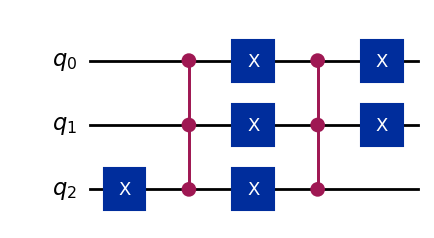

In [8]:
marked_states = ["011","100"]

oracle = grover_oracle(marked_states)
oracle.draw(output="mpl")

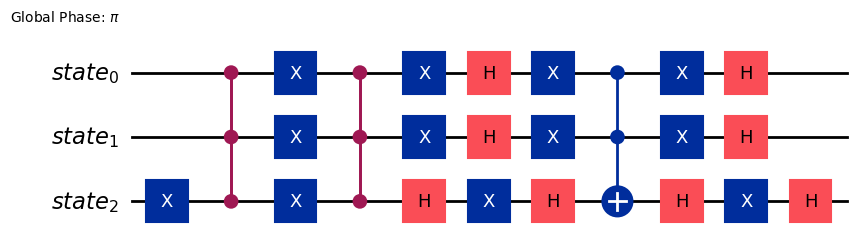

In [9]:
grover_op = GroverOperator(oracle)
grover_op.decompose().draw(output="mpl")

In [11]:
optimal_num_iterations = math.floor(
    math.pi / (4*math.asin(math.sqrt(len(marked_states) / 2**grover_op.num_qubits)))
)

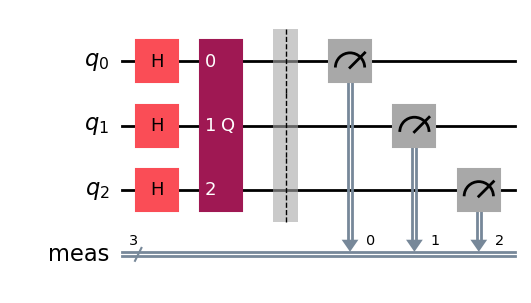

In [13]:
qc = QuantumCircuit(grover_op.num_qubits)
# create even superposition of all basis states
qc.h(range(grover_op.num_qubits))
# Apply Grover operator the optimal number of times
qc.compose(grover_op.power(optimal_num_iterations), inplace=True)
# Measure all qubits
qc.measure_all()
qc.draw(output="mpl")

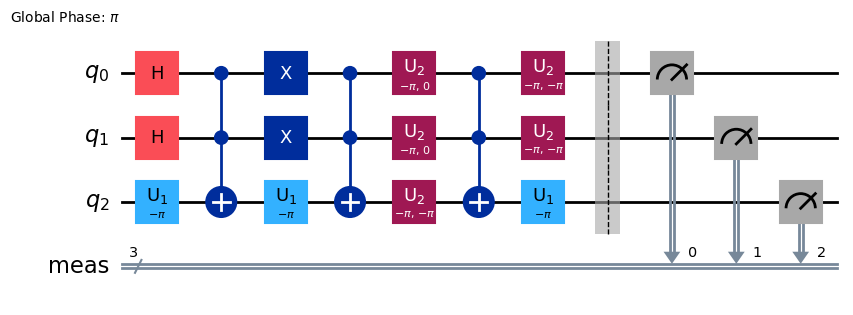

In [16]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# Assuming `backend` and `qc` (quantum circuit) are already defined
target = backend.target

# Generate a preset pass manager with optimization level 3
pm = generate_preset_pass_manager(target=target, optimization_level=3)

# Run the pass manager on the quantum circuit
circuit_isa = pm.run(qc)

# Draw the resulting circuit
circuit_isa.draw(output="mpl", idle_wires=False)


In [21]:
# To run on local simulator
# 1. Use the statevectorSampler from qiskit.primitives instead
sampler = Sampler(backend=backend)
sampler.options.default_shots = 100
result = sampler.run([circuit_isa]).result()
dist = result[0].data.meas.get_counts()

C:\Users\KIIT\AppData\Local\Temp\ipykernel_22092\2325024138.py:3: DeprecationWarning: The 'backend' keyword arguments are deprecated as of qiskit-ibm-runtime 0.24.0 and will be removed no sooner than 3 months after the release date. Please use the 'mode' parameter instead.
  sampler = Sampler(backend=backend)


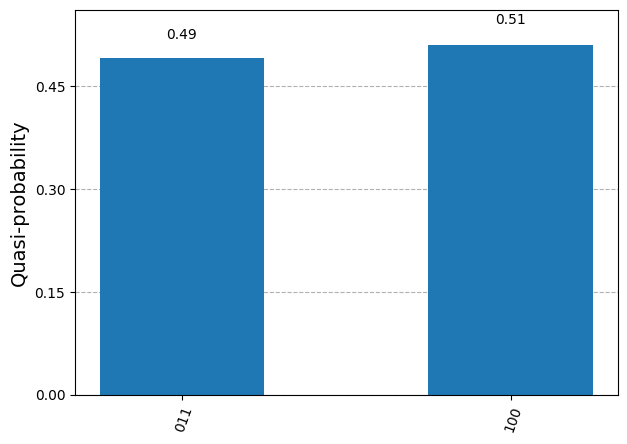

In [22]:
plot_distribution(dist)

In [23]:
# To run on local simulator
# 1. Use the statevectorSampler from qiskit.primitives instead
sampler = Sampler(backend=backend)
sampler.options.default_shots = 10000
result = sampler.run([circuit_isa]).result()
dist = result[0].data.meas.get_counts()

C:\Users\KIIT\AppData\Local\Temp\ipykernel_22092\3534116626.py:3: DeprecationWarning: The 'backend' keyword arguments are deprecated as of qiskit-ibm-runtime 0.24.0 and will be removed no sooner than 3 months after the release date. Please use the 'mode' parameter instead.
  sampler = Sampler(backend=backend)


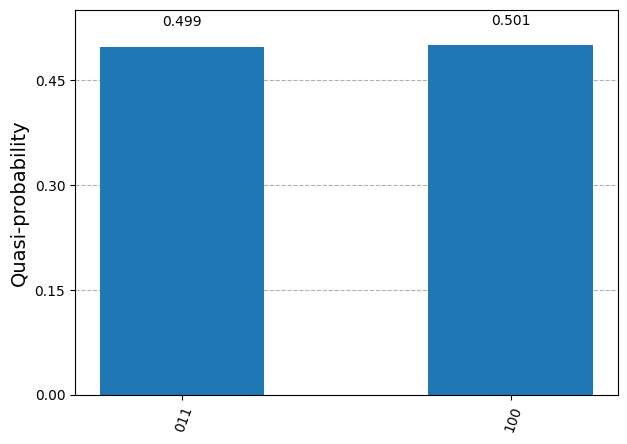

In [24]:
plot_distribution(dist)

In [25]:
# To run on local simulator
# 1. Use the statevectorSampler from qiskit.primitives instead
sampler = Sampler(backend=backend)
sampler.options.default_shots = 1000000
result = sampler.run([circuit_isa]).result()
dist = result[0].data.meas.get_counts()

C:\Users\KIIT\AppData\Local\Temp\ipykernel_22092\4249041838.py:3: DeprecationWarning: The 'backend' keyword arguments are deprecated as of qiskit-ibm-runtime 0.24.0 and will be removed no sooner than 3 months after the release date. Please use the 'mode' parameter instead.
  sampler = Sampler(backend=backend)


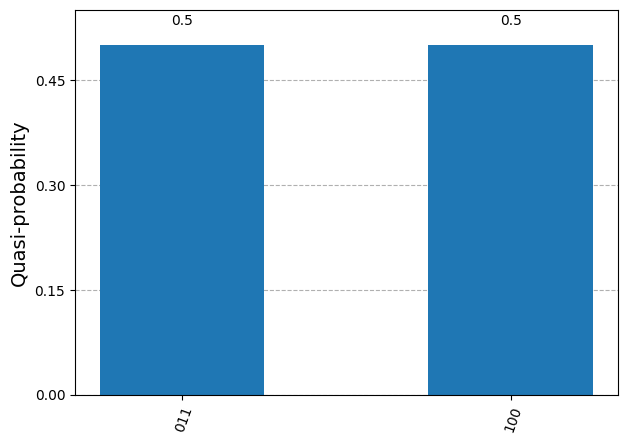

In [26]:
plot_distribution(dist)